# M2A10 - Modelos Pré-Treinados

Na prática de hoje vamos utilizar modelos de aprendizado profundo pré-treinados, e para isso vamos utilizar [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Modelos Pré-treinados
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [2]:
!pip install torch torchvision

Importar as bibliotecas e Ler Imagens do Disco

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

In [4]:
# TODO Atualize o path da imagem.
image = cv2.imread("dog.jpeg")

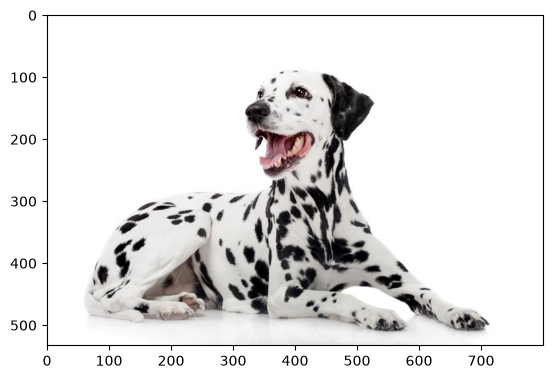

In [5]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Modelos Pré-Treinados

A primeira coisa para utilizar modelos pré-treinados é carregar seus pesos pré-treinados, utilizamos a biblioteca PyTorch para isso.

In [6]:
# Definindo os pesos a serem utilizados.
weights = torchvision.models.VGG16_Weights.DEFAULT

# Carregar os labels do dataset.
imagenet_labels = weights.meta["categories"] 

# Carregar o modelo.
vgg_16_model = torchvision.models.vgg16(weights)

# Criando o pipeline de transformações de pré-processamento dos dados.
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

c:\Users\kaiog\Documents\nexvisual-computer-vision\modulos\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [7]:
# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()


# Pré processando a imagem.
image_tensor = preprocess(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
input_batch = image_tensor.unsqueeze(0) 


In [8]:
# Escolhendo o dispositivo a ser utilizado GPU se disponível.
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    vgg_16_model.to('cuda')

# Rodando a inferência.
with torch.no_grad():
    output = vgg_16_model(input_batch)

# Calculando as probabilidades das classes.
probabilities = torch.nn.functional.softmax(output[0], dim=0)

Classe predita para imagem: dalmatian


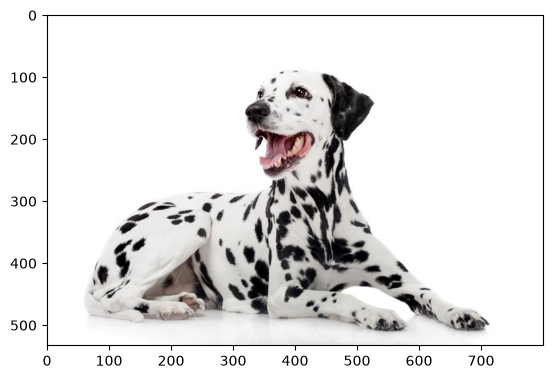

In [9]:
# Validando a classe prevista.
print(f"Classe predita para imagem: {imagenet_labels[torch.argmax(probabilities)]}")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'EntleBucher'),
  Text(1, 0, 'boxer'),
  Text(2, 0, 'American Staffordshire terrier'),
  Text(3, 0, 'kuvasz'),
  Text(4, 0, 'bluetick'),
  Text(5, 0, 'muzzle'),
  Text(6, 0, 'German short-haired pointer'),
  Text(7, 0, 'English setter'),
  Text(8, 0, 'Great Dane'),
  Text(9, 0, 'dalmatian')])

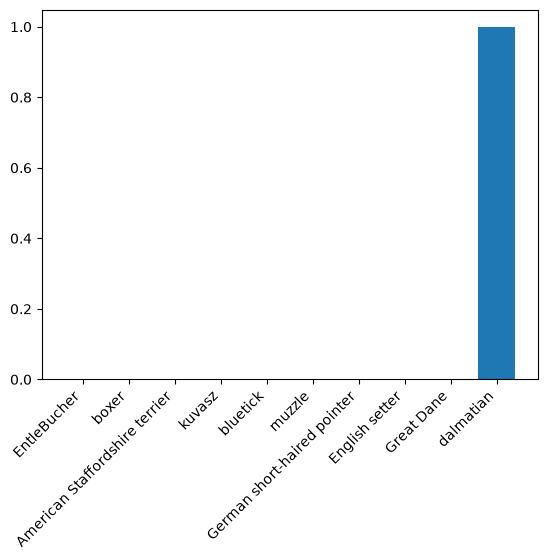

In [10]:
# Criar conjunto de labels e probabilidades, e ordenar.
set_labels_probs = list(zip(imagenet_labels, list(probabilities.cpu().numpy())))
set_labels_probs = sorted(set_labels_probs, key=lambda x: x[1])

# Pega as N classes mais prováveis.
num = 10
most_probable_classes = set_labels_probs[-num:]

# Criar as listas para o plot.
labels, probs = zip(*most_probable_classes)

# Observando as probabilidades.
plt.bar(labels, probs)
plt.xticks(rotation=45, ha='right') # Rotate labels by 45 degrees and align right


E assim terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas iremo avançar ainda mais no mundo de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [ ] Rode a inferência com outra imagem.
- [ ] Tente utilizar outro modelo pré-treinado da mesma forma que utilizamos o modelo VGG 16.

In [21]:
image = cv2.imread("cat.jpg")

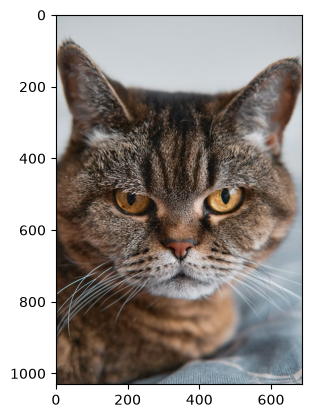

In [22]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

Classe predita para imagem: tabby


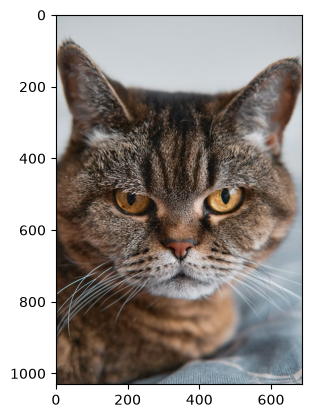

In [30]:
# Definindo os pesos a serem utilizados.
weights = torchvision.models.VGG16_Weights.DEFAULT

# Carregar os labels do dataset.
imagenet_labels = weights.meta["categories"] 

# Carregar o modelo.
vgg_16_model = torchvision.models.vgg16(weights)

# Criando o pipeline de transformações de pré-processamento dos dados.
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()


# Pré processando a imagem.
image_tensor = preprocess(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
input_batch = image_tensor.unsqueeze(0) 

# Escolhendo o dispositivo a ser utilizado GPU se disponível.
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    vgg_16_model.to('cuda')

# Rodando a inferência.
with torch.no_grad():
    output = vgg_16_model(input_batch)

# Calculando as probabilidades das classes.
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Validando a classe prevista.
print(f"Classe predita para imagem: {imagenet_labels[torch.argmax(probabilities)]}")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

# Criar conjunto de labels e probabilidades, e ordenar.
set_labels_probs = list(zip(imagenet_labels, list(probabilities.cpu().numpy())))
set_labels_probs = sorted(set_labels_probs, key=lambda x: x[1])

# Pega as N classes mais prováveis.
num = 10
most_probable_classes = set_labels_probs[-num:]

# Criar as listas para o plot.
labels, probs = zip(*most_probable_classes)





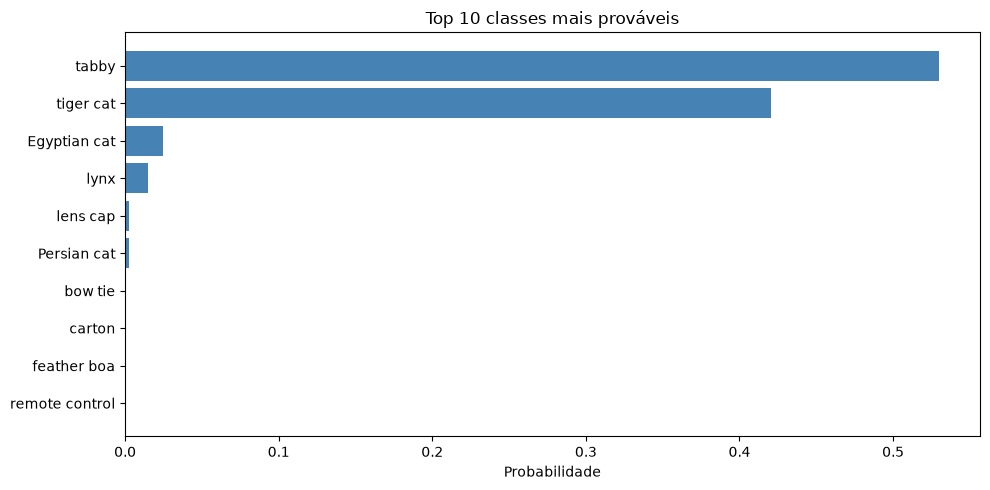

In [28]:
# Mostrar o gráfico separadamente
plt.figure(figsize=(10,5))
plt.barh(labels, probs, color='steelblue')
plt.xlabel("Probabilidade")
plt.title("Top 10 classes mais prováveis")
plt.tight_layout()
plt.show()

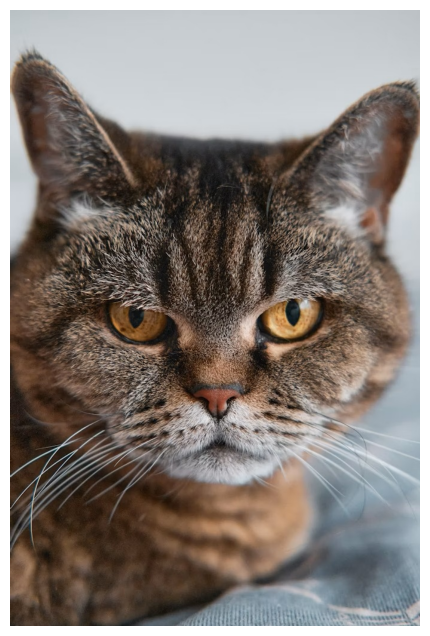

In [32]:
plt.figure(figsize=(6,8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


- [X] Tente utilizar outro modelo pré-treinado da mesma forma que utilizamos o modelo VGG 16.

In [34]:
if image is None:
    raise FileNotFoundError("Não foi possível carregar a imagem.")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

 Carregar modelo ResNet50

In [35]:
weights = torchvision.models.ResNet50_Weights.DEFAULT

imagenet_labels = weights.meta["categories"]

model = torchvision.models.resnet50(weights=weights)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Pré-processamento

In [38]:
import torchvision.transforms as transforms

image_tensor = transforms.ToTensor()(image_rgb)

preprocess = weights.transforms()

input_tensor = preprocess(image_tensor)

GPU

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
input_batch = input_batch.to(device)

Inferência

In [40]:
with torch.no_grad():
    output = model(input_batch)

probabilities = torch.nn.functional.softmax(output[0], dim=0)

Top 5 previsões

In [41]:
top5 = torch.topk(probabilities, 5)

print("Top 5 previsões:\n")

for prob, idx in zip(top5.values, top5.indices):
    print(
        f"{imagenet_labels[idx]}: "
        f"{prob.item()*100:.2f}%"
    )


Top 5 previsões:

tiger cat: 30.68%
tabby: 10.88%
Egyptian cat: 1.33%
Persian cat: 1.00%
lynx: 0.91%


Plot

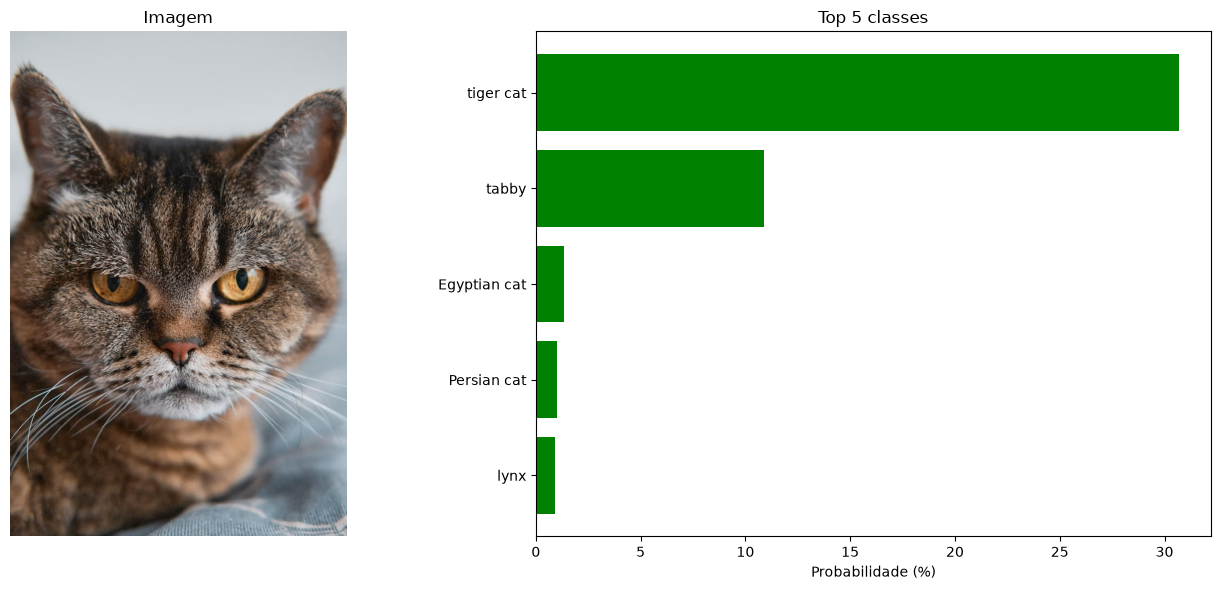

In [42]:
labels = [imagenet_labels[i] for i in top5.indices.cpu().numpy()]
probs = [p.item()*100 for p in top5.values.cpu().numpy()]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ax1.imshow(image_rgb)
ax1.set_title("Imagem")
ax1.axis("off")

ax2.barh(labels[::-1], probs[::-1], color="green")
ax2.set_xlabel("Probabilidade (%)")
ax2.set_title("Top 5 classes")

plt.tight_layout()
plt.show()